# Extracting and Visualizing Stock Data

In [31]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

## Use `yfinance` to extract Tesla stock data

We will use the `yfinance` library in Python to create a Ticker object. This object acts as a gateway to all the data related to a specific company. Once created, we can use it to pull historical prices, company info, and financial statements.

In [32]:
# Create a Ticker object for Tesla using its symbol 'TSLA'
tesla = yf.Ticker("TSLA")

# Extract historical stock data
# .history() method gets the price for a specific period
# period="max" retrieves all available historical data
tesla_data = tesla.history(period="max")

# 3. Reset the index of the DataFrame
# inplace=True applies the change to tesla_data directly
tesla_data.reset_index(inplace=True)

# Display the first few rows of the data
print(tesla_data.head())

                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


#### Implementation

+ `reset_index(inplace=True)`: By default, `yfinance` uses the Date as the index. Resetting the index turns those dates into a data column and gives each row a numerical ID starting at 0. This is helpful if we want to perform operations specifically on the Date column later.

## Use Webscraping to Extract Tesla Revenue Data

To extract the revenue data, we will use the `requests` library to fetch the webpage and `BeautifulSoup` to parse the HTML structure.

We may neet to install the following libraries if we haven't already:

`pip install requests beautifulsoup4 html5lib`

In [33]:
# Download the webpage
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
response = requests.get(url)

# Save the text of the response
html_data = response.text

# Parse the html data using BeautifulSoup
soup = BeautifulSoup(html_data, "lxml")

# Extract the table with Tesla Revenue
tables = pd.read_html(str(soup))

# Based on the page structure, the second table usually contains the Quarterly Revenue
tesla_revenue = tables[1]

# Rename columns to Date and Revenue
tesla_revenue.columns = ["Date", "Revenue"]

# Remove comma and dollar sign from the Revenue column
# We use regex=True to ensure all instances of these symbols are caught
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace(r'[\$,]', "", regex=True)

# Remove null or empty strings
# First, drop actual null values
tesla_revenue.dropna(inplace=True)

# Second, filter out rows where Revenue might be an empty string
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

# Display the last five rows to verify extraction
print(tesla_revenue.tail())

          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27


## Use `yfinance` to Extract GameStop Stock Data

We will extract the data for GameStop (GME). This process is identical to the one we used for Tesla, but we will simply swap the ticker symbol.

In [34]:
# Create a ticker object for GameStop
gme = yf.Ticker("GME")

# Extract stock information with the period set to "max"
gme_data = gme.history(period="max")

# Reset the index of the DataFrame
gme_data.reset_index(inplace=True)

# Display the first five rows
print(gme_data.head())

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691666  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683251  1.687459  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


## Use Webscraping to Extract GME Revenue Data
We will extract and clean the GameStop (GME) revenue data using a similar process to what we used for Tesla.

In [35]:
# Download the webpage
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
response = requests.get(url)
html_data_2 = response.text

# Parse the html data
soup = BeautifulSoup(html_data_2, "lxml")

# Extract the GameStop Revenue table
gme_revenue = pd.read_html(str(soup))[1]

# Rename the columns to Date and Revenue
gme_revenue.columns = ["Date", "Revenue"]

# Remove comma and dollar sign from Revenue
gme_revenue['Revenue'] = gme_revenue["Revenue"].str.replace(r'[\$,]', '', regex=True)

# Remove null or empty strings
# First, drop actual null values
gme_revenue.dropna(inplace=True)

# Second, filter out rows where Revenue might be an empty string
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

# Display the last five rows
print(gme_revenue.tail())

          Date Revenue
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709


### Define Graphing Function

In this section, we define the function `make_graph`. It takes a dataframe with stock data , a dataframe with revenue data, and the name of the stock.


In [36]:
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data['Date'] <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data['Date'] <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific['Date']), 
                 stock_data_specific['Close'].astype("float"),
                 label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($USD)")
    axes[0].set_xlabel("Date")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific['Date']),
                 revenue_data_specific['Revenue'].astype("float"),
                 label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()
    

#### Implementation Details

+ `plt.subplots(2, 1)` creates a "stack" of two graphs. The top graph shows the stock price volatility, and the bottom graph shows the quarterly financial performance, allowing us to see if the stock price spike was driven by earnings or other market factors.

+ Inside the function, the lines `stock_data[stock_data.Date <= '2021-06-14']` and `revenue_data[revenue_data.Date <= '2021-04-30']` act as a "zoom" tool. Even though you extracted "max" data earlier, the graph will focus strictly on the period leading up to the summer of 2021.

## Plot Tesla Stock Graph

To use the make_graph function for Tesla, we need to ensure the Revenue column is converted to a numeric format (float), as we previously only cleaned the strings. Matplotlib cannot plot "text" numbers; they must be actual numerical values.

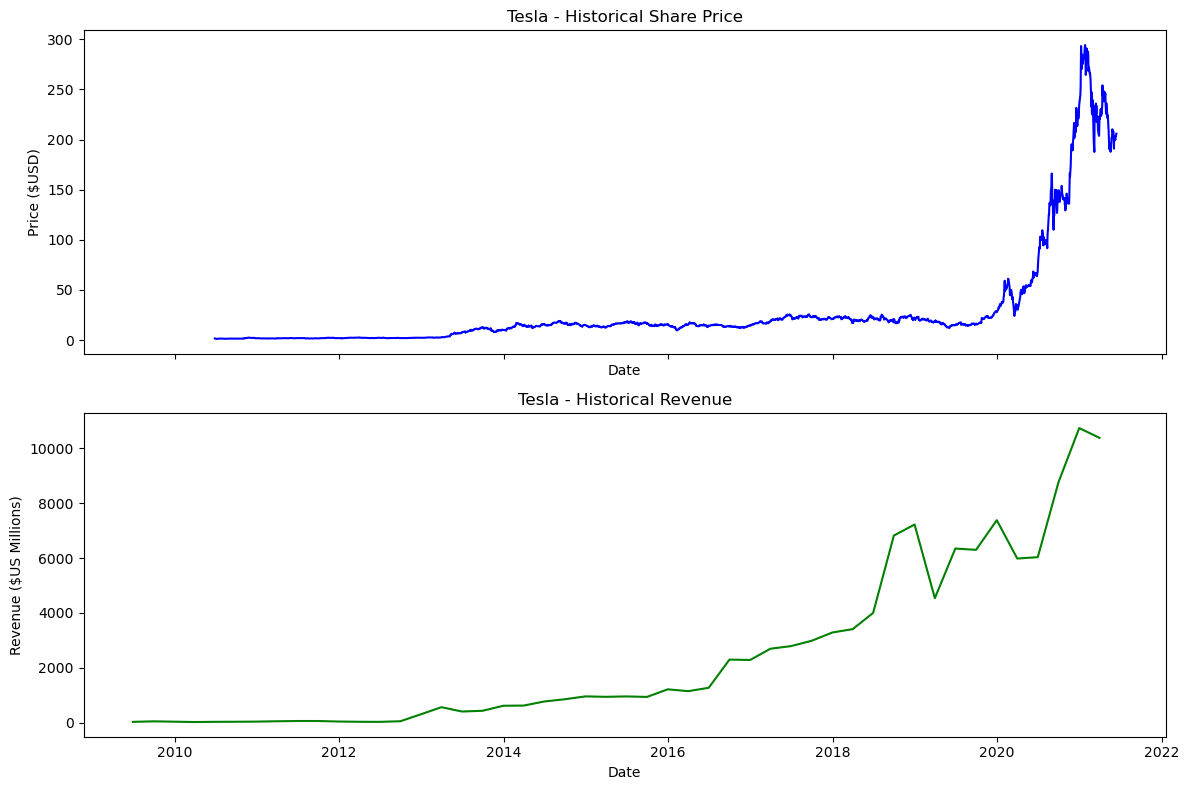

In [37]:
# Ensure the Revenue column is a float so it can be graphed
# This convert the cleaned strings into actual numbers
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].astype(float)

# Call the make_graph function
make_graph(tesla_data, tesla_revenue, 'Tesla')

#### What the Graph Shows

+ **Historical Share Price (Blue)**

    + For nearly a decade (2010–2019), Tesla's stock price remained relatively low and stable, mostly staying under $50.

    + Starting in early 2020, the price entered a parabolic phase. It climbed from under $100 to nearly $300 in a very short timeframe. This reflects [massive investor optimism and Tesla's entry into the S&P 500](https://press.spglobal.com/2020-11-16-Tesla-Set-to-Join-S-P-500).

+ **Historical Revenue (Green)**

    + Unlike the stock price, which stayed flat for a long time, the revenue shows a steady, healthy upward climb starting around 2013.

    + We can see that as Tesla scaled its vehicle production (Model 3 and Model Y), the revenue started hitting new records. By 2021, quarterly revenue exceeded $10 Billion.

    + Notice the dip and recovery around 2019-2020; this highlights [the challenges of production scaling](https://www.reuters.com/business/autos-transportation/tesla-warns-challenges-scaling-up-production-2020-09-22/) followed by the [success of new gigafactories](https://en.wikipedia.org/wiki/Tesla,_Inc.#:~:text=During%202020%2C%20its%20share%20price,valuable%20company%20in%20the%20US.).

## Plot GameStop Stock Graph

To plot the GameStop graph, we will follow the same logic we used for Tesla. We must ensure the `Revenue` column is converted to a numeric type (float) so the plotting library can read the values correctly.

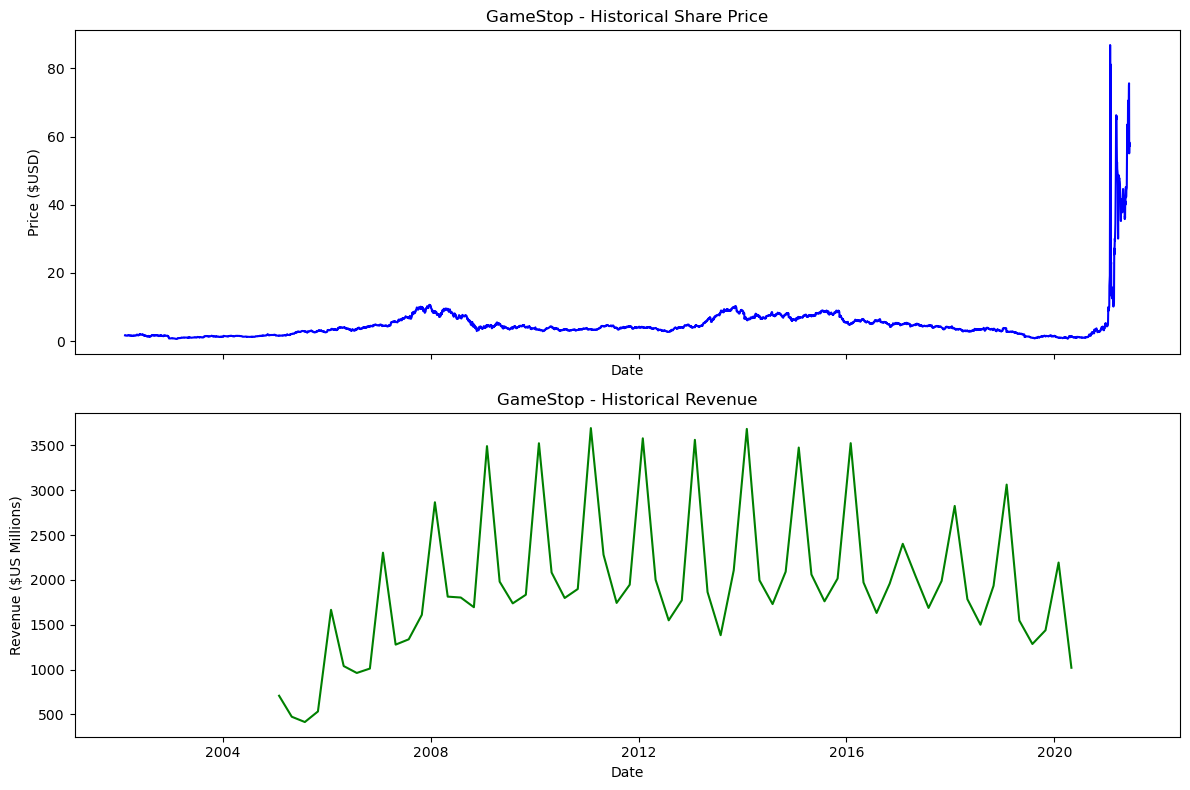

In [38]:
# Ensure the Revenue column is a float so it can be graphed
# This convert the cleaned strings into actual numbers
gme_revenue["Revenue"] = gme_revenue["Revenue"].astype(float)

# Call the make_graph function
make_graph(gme_data, gme_revenue, 'GameStop')

#### What the Graph Shows

This graph provides a side-by-side comparison of GameStop's (GME) historical stock price performance against its historical revenue. It is a classic visualization used to compare a company's revenue with its stock price.

1. **Top Graph: Historical Share Price (Blue)**

+ This graph shows the price of a GME share from roughly 2002 to 2021.

    + **Long-term Stability**: For nearly 20 years, the stock price remained relatively low, fluctuating between $2 and $10 (split-adjusted).

    + **The 2021 Spike**: On the far right, we see a massive, almost vertical blue line. This represents the ["Short Squeeze" event of January 2021](https://en.wikipedia.org/wiki/GameStop_short_squeeze), where the price surged from under $20 to nearly $500 in a matter of days due to retail investor interest and social media momentum.

2. **Bottom Graph: Historical Revenue (Green)**

+ This graph tracks how much money the company actually brought in each quarter.

    + **Seasonality**: Notice the "zigzag" or "sawtooth" pattern. This is a hallmark of retail businesses. Revenue peaks every year during the Q4 holiday season and drops in Q1.

    + **The Trend**: While the stock price saw a record-breaking surge in 2021, the revenue graph shows that the company's actual sales were declining from their peak around 2011-2016. By 2020-2021, the revenue was at its lowest level in over a decade.

#### Key Observation

+ The most important takeaway from looking at these two graphs together is the lack of correlation in 2021.

    + In a fundamental market, we would expect the stock price (blue) to go up because the revenue (green) is growing.

    + Actually, in early 2021, GameStop's stock price skyrocketed to record highs while its actual revenue was hitting a long-term low. This visually proves that the 2021 price surge was driven by market technicals and investor sentiment rather than the company's financial growth.